# Savegame Analysis Workbench

Build or refresh the raw savegame parquet dataset first:

```bash
uv run ppc savegame-notebooks build
```

All analysis below uses Polars lazy scans over `graphs/dataset`. Change selector variables in the setup cell, then rerun the relevant section.

In [1]:
%matplotlib inline

import importlib
from eu5gameparser.savegame import notebook_workbench as wb
wb = importlib.reload(wb)

DATA_ROOT = None       # None means graphs/dataset under the constructor repo
LOAD_ORDER_PATH = None # None means constructor.load_order.toml under the constructor repo
PLAYTHROUGH = None     # None means latest playthrough
START_DATE = None      # example: 13370101
END_DATE = None        # example: 14000101
SNAPSHOT_DATE = None   # None means latest selected snapshot

GOOD_SEARCH = "victuals"
MARKET_SEARCH = None   # None means all markets; set to e.g. "london" for market drilldowns
BUILDING_SEARCH = "cookery"
PM_DRILLDOWN_SEARCH = None  # set to e.g. "packing" only for PM flow/value drilldowns
COUNTRY_SEARCH = "england"

GROUP_BY = "super_region"
BUILDING_SCOPE = "super_region"
FLOW_GROUP_BY = ("flow_table", "market")
CONSUMPTION_GROUP_BY = "bucket"
IMBALANCE_SORT = "mean_flow"  # mean_flow, total_flow, mean_market_cap, total_market_cap
AGG = "sum"           # sum, mean, median over raw selected rows
TOP_N = 6
BUCKET_YEARS = 25
START_YEAR = 1337
POPULATION_METRIC = "total_population"
FOOD_RANK_BY = "food_fill_ratio"
BUILDING_METRIC = "level"

workbench = wb.open_workbench(wb.WorkbenchConfig.from_mapping(globals()))
ds = workbench.dataset
snapshots = workbench.snapshots


## Search And Snapshot Context

In [2]:
workbench.print_selection()
goods_matches, market_matches, building_matches, pm_matches, country_matches, snapshot_summary = workbench.preview()


repo: /home/jan/development/ProsperOrPerishConstructor
data: /home/jan/development/ProsperOrPerishConstructor/graphs/dataset
data mode: raw
playthrough: 5bb2f61a_ee6a_420e_9921_4fd86ae364b5
good: Victuals (victuals)
market search: all markets
building search: cookery
pm drilldown search: none


## Global Composition Over Time

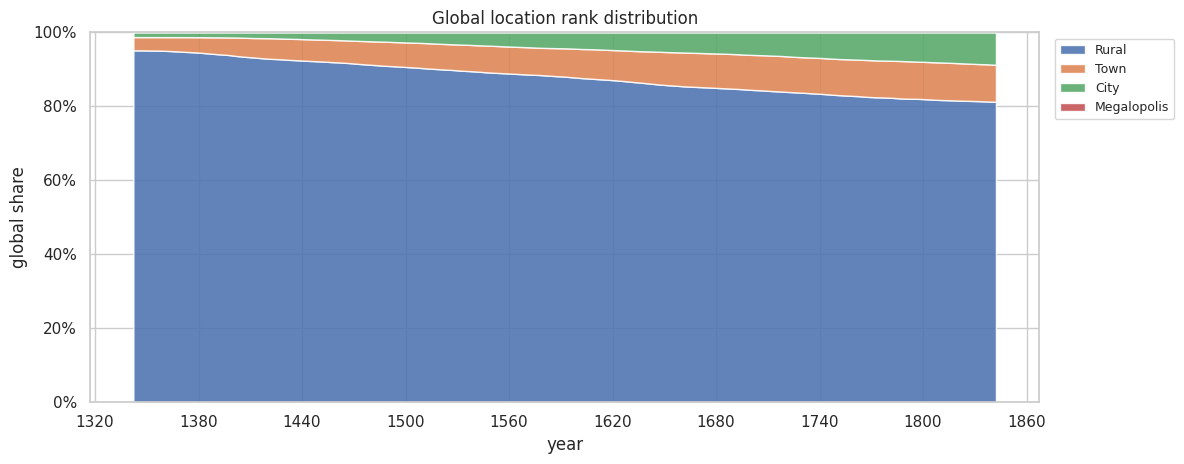

In [3]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display
from matplotlib.ticker import MaxNLocator, PercentFormatter

LOCATION_RANK_ORDER = ["rural_settlement", "town", "city", "megalopolis"]
LOCATION_RANK_LABELS = {
    "rural_settlement": "Rural",
    "town": "Town",
    "city": "City",
    "megalopolis": "Megalopolis",
}


def _selected_raw_locations() -> pl.LazyFrame:
    files = ds.fact_files("locations", playthrough_id=workbench.playthrough)
    if not files:
        return pl.DataFrame().lazy()
    frame = pl.scan_parquet(
        [str(path) for path in files],
        hive_partitioning=False,
        missing_columns="insert",
        extra_columns="ignore",
    )
    if START_DATE is not None:
        frame = frame.filter(pl.col("date_sort") >= int(START_DATE))
    if END_DATE is not None:
        frame = frame.filter(pl.col("date_sort") <= int(END_DATE))
    return frame.with_columns(
        (
            pl.col("year").cast(pl.Float64)
            + (pl.col("month").cast(pl.Float64) - 1.0) / 12.0
            + (pl.col("day").cast(pl.Float64) - 1.0) / 365.25
        ).alias("plot_year")
    )


def _plot_percent_stack(
    frame: pl.DataFrame,
    *,
    category: str,
    sort_col: str,
    title: str,
) -> None:
    if frame.is_empty() or not {"plot_year", "date_sort", category, "percent"}.issubset(frame.columns):
        print("No rows")
        return

    pivot = (
        frame.sort(["date_sort", sort_col])
        .pivot(
            index=["plot_year", "date_sort", "date"],
            on=category,
            values="percent",
            aggregate_function="first",
        )
        .sort("date_sort")
        .fill_null(0)
    )
    categories = [
        value
        for value in frame.sort(sort_col).get_column(category).unique(maintain_order=True).to_list()
        if value in pivot.columns
    ]
    if not categories:
        print("No rows")
        return

    x_values = pivot.get_column("plot_year").to_list()
    series = [pivot.get_column(value).to_list() for value in categories]
    fig, ax = plt.subplots(figsize=(12, 4.8))
    if len(x_values) == 1:
        bottom = 0.0
        for label, values in zip(categories, series, strict=True):
            value = values[0] if values else 0.0
            ax.bar(x_values[0], value, bottom=bottom, width=0.45, label=label)
            bottom += value
        ax.set_xlim(x_values[0] - 0.75, x_values[0] + 0.75)
    else:
        ax.stackplot(x_values, series, labels=categories, alpha=0.88)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title(title)
    ax.set_xlabel("year")
    ax.set_ylabel("global share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)


locations_raw = _selected_raw_locations()
location_rank_categories = pl.DataFrame(
    {
        "rank": LOCATION_RANK_ORDER,
        "rank_label": [LOCATION_RANK_LABELS[value] for value in LOCATION_RANK_ORDER],
        "rank_sort": list(range(len(LOCATION_RANK_ORDER))),
    }
)
location_rank_counts = (
    locations_raw.filter(pl.col("rank").is_in(LOCATION_RANK_ORDER))
    .group_by(["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year", "rank"])
    .agg(pl.len().alias("locations"))
    .collect()
)
location_rank_snapshots = location_rank_counts.select(
    ["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"]
).unique()
location_rank_distribution = (
    location_rank_snapshots.join(location_rank_categories, how="cross")
    .join(
        location_rank_counts,
        on=["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year", "rank"],
        how="left",
    )
    .with_columns(pl.col("locations").fill_null(0))
    .with_columns(pl.sum("locations").over("snapshot_id").alias("total_locations"))
    .with_columns(
        pl.when(pl.col("total_locations") > 0)
        .then(pl.col("locations") / pl.col("total_locations") * 100.0)
        .otherwise(0.0)
        .alias("percent")
    )
    .sort(["date_sort", "rank_sort"])
)

_plot_percent_stack(
    location_rank_distribution,
    category="rank_label",
    sort_col="rank_sort",
    title="Global location rank distribution",
)


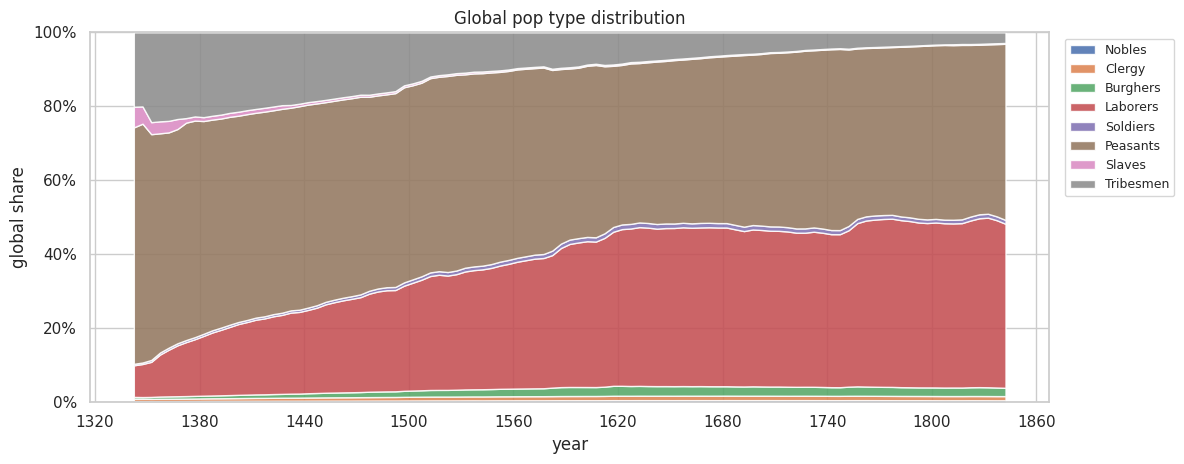

In [4]:
POP_TYPE_ORDER = [
    "nobles",
    "clergy",
    "burghers",
    "laborers",
    "soldiers",
    "peasants",
    "slaves",
    "tribesmen",
]
POP_TYPE_LABELS = {value: value.replace("_", " ").title() for value in POP_TYPE_ORDER}

locations_raw = _selected_raw_locations()
location_columns = set(locations_raw.collect_schema().names())
population_columns = [
    f"population_{pop_type}"
    for pop_type in POP_TYPE_ORDER
    if f"population_{pop_type}" in location_columns
]

if population_columns:
    pop_type_wide = (
        locations_raw.group_by(["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"])
        .agg([
            pl.sum(column).alias(column.removeprefix("population_"))
            for column in population_columns
        ])
        .sort("date_sort")
        .collect()
    )
    pop_type_distribution = (
        pop_type_wide.unpivot(
            index=["snapshot_id", "date_sort", "year", "month", "day", "date", "plot_year"],
            variable_name="pop_type",
            value_name="population",
        )
        .with_columns(
            pl.col("pop_type").replace_strict(POP_TYPE_LABELS, default=pl.col("pop_type")).alias("pop_type_label"),
            pl.col("pop_type").replace_strict(
                {value: index for index, value in enumerate(POP_TYPE_ORDER)},
                default=99,
            ).alias("pop_type_sort"),
        )
        .with_columns(pl.sum("population").over("snapshot_id").alias("total_population"))
        .with_columns(
            pl.when(pl.col("total_population") > 0)
            .then(pl.col("population") / pl.col("total_population") * 100.0)
            .otherwise(0.0)
            .alias("percent")
        )
        .sort(["date_sort", "pop_type_sort"])
    )
else:
    pop_type_distribution = pl.DataFrame()

_plot_percent_stack(
    pop_type_distribution,
    category="pop_type_label",
    sort_col="pop_type_sort",
    title="Global pop type distribution",
)


## Population / Locations Over Time

In [5]:
population = workbench.population()
population_latest = population.latest
population_delta = population.delta
population_ts = population.time_series
population_ts_top = population.top_time_series
population_global = population.global_time_series


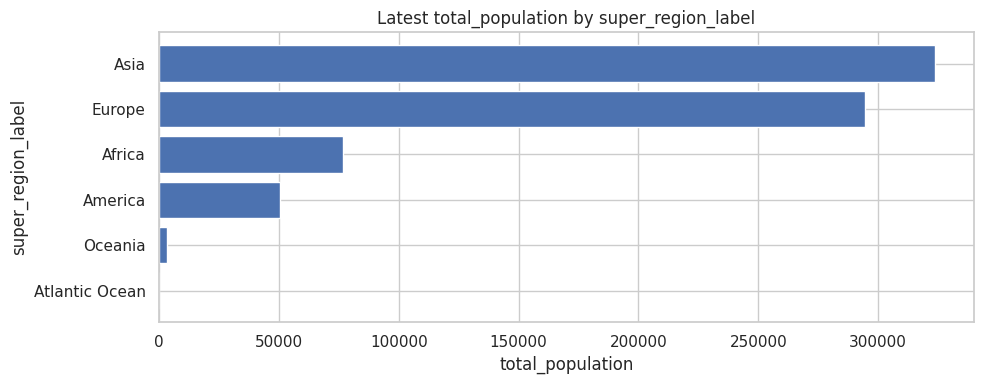

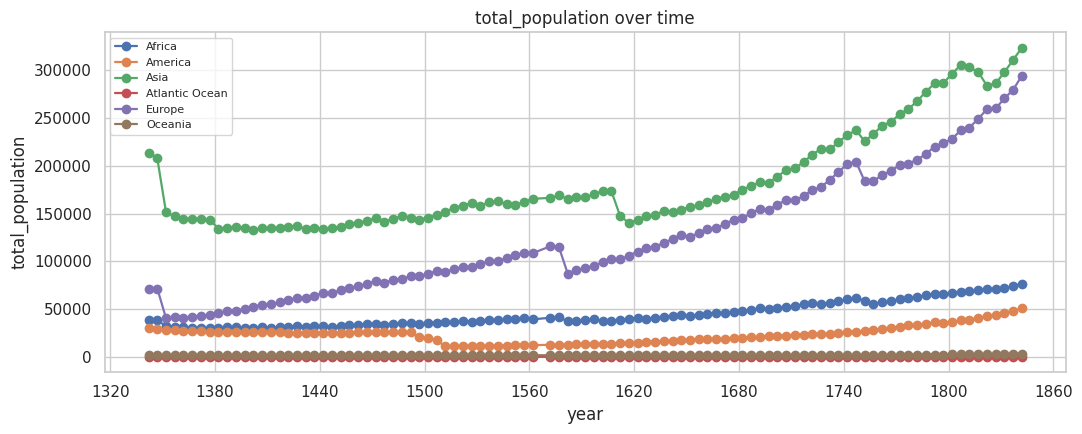

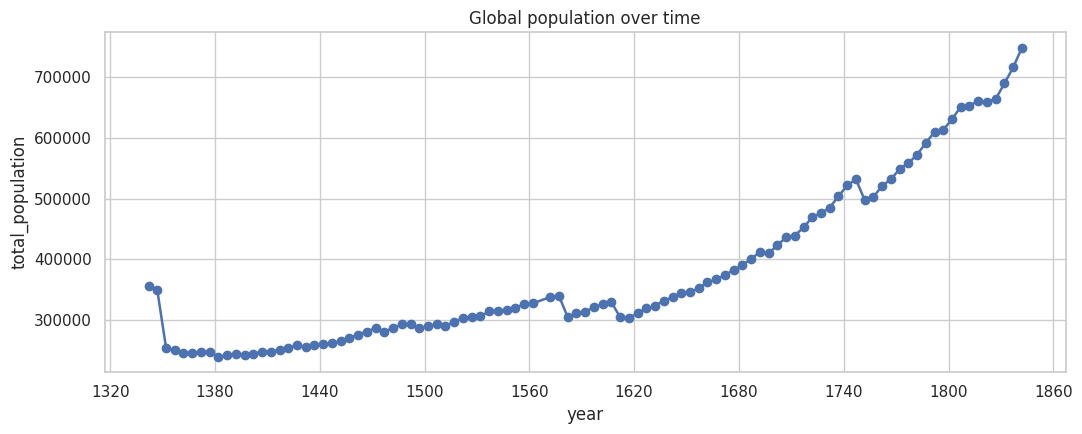

In [6]:
workbench.plot_population(population)


## Goods And Markets

In [7]:
goods = workbench.goods()
goods_global_ts = goods.global_time_series
market_scarcity = goods.scarcity
goods_imbalance = goods.imbalance
goods_imbalance_all = goods.goods_imbalance_all
market_flow_value = goods.flow_value


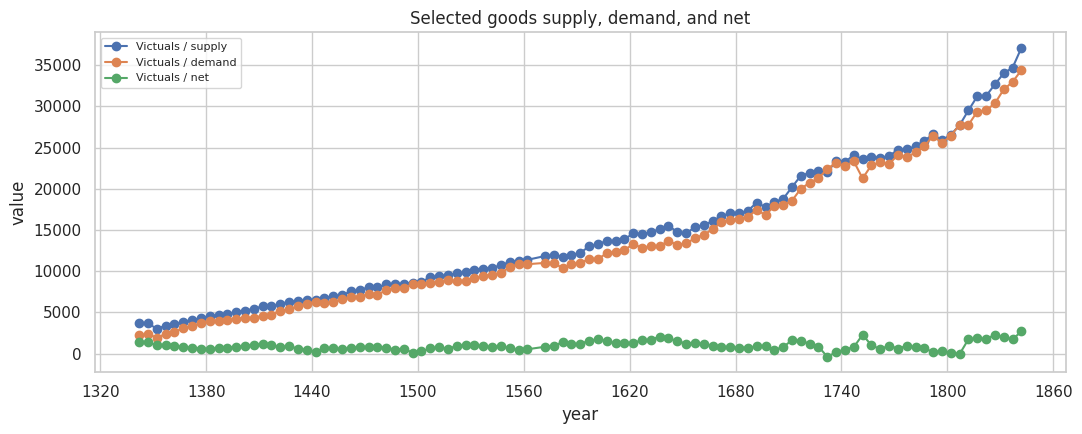

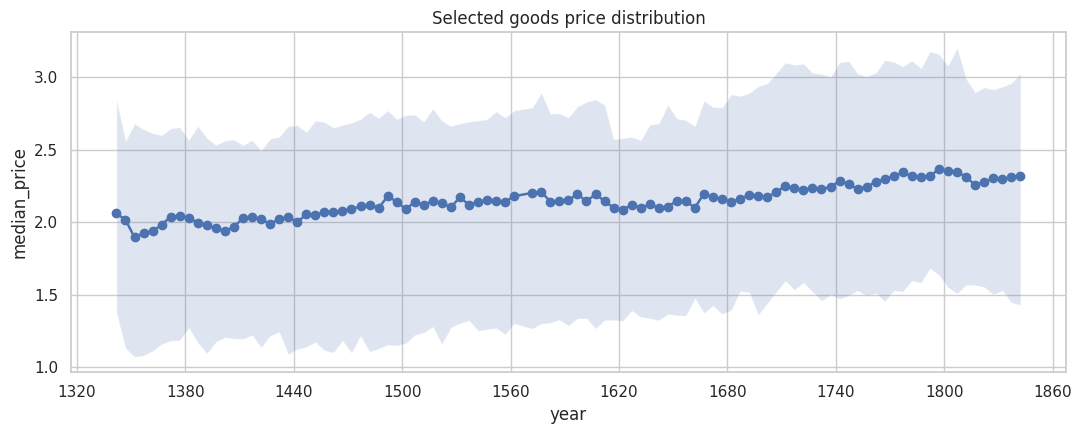

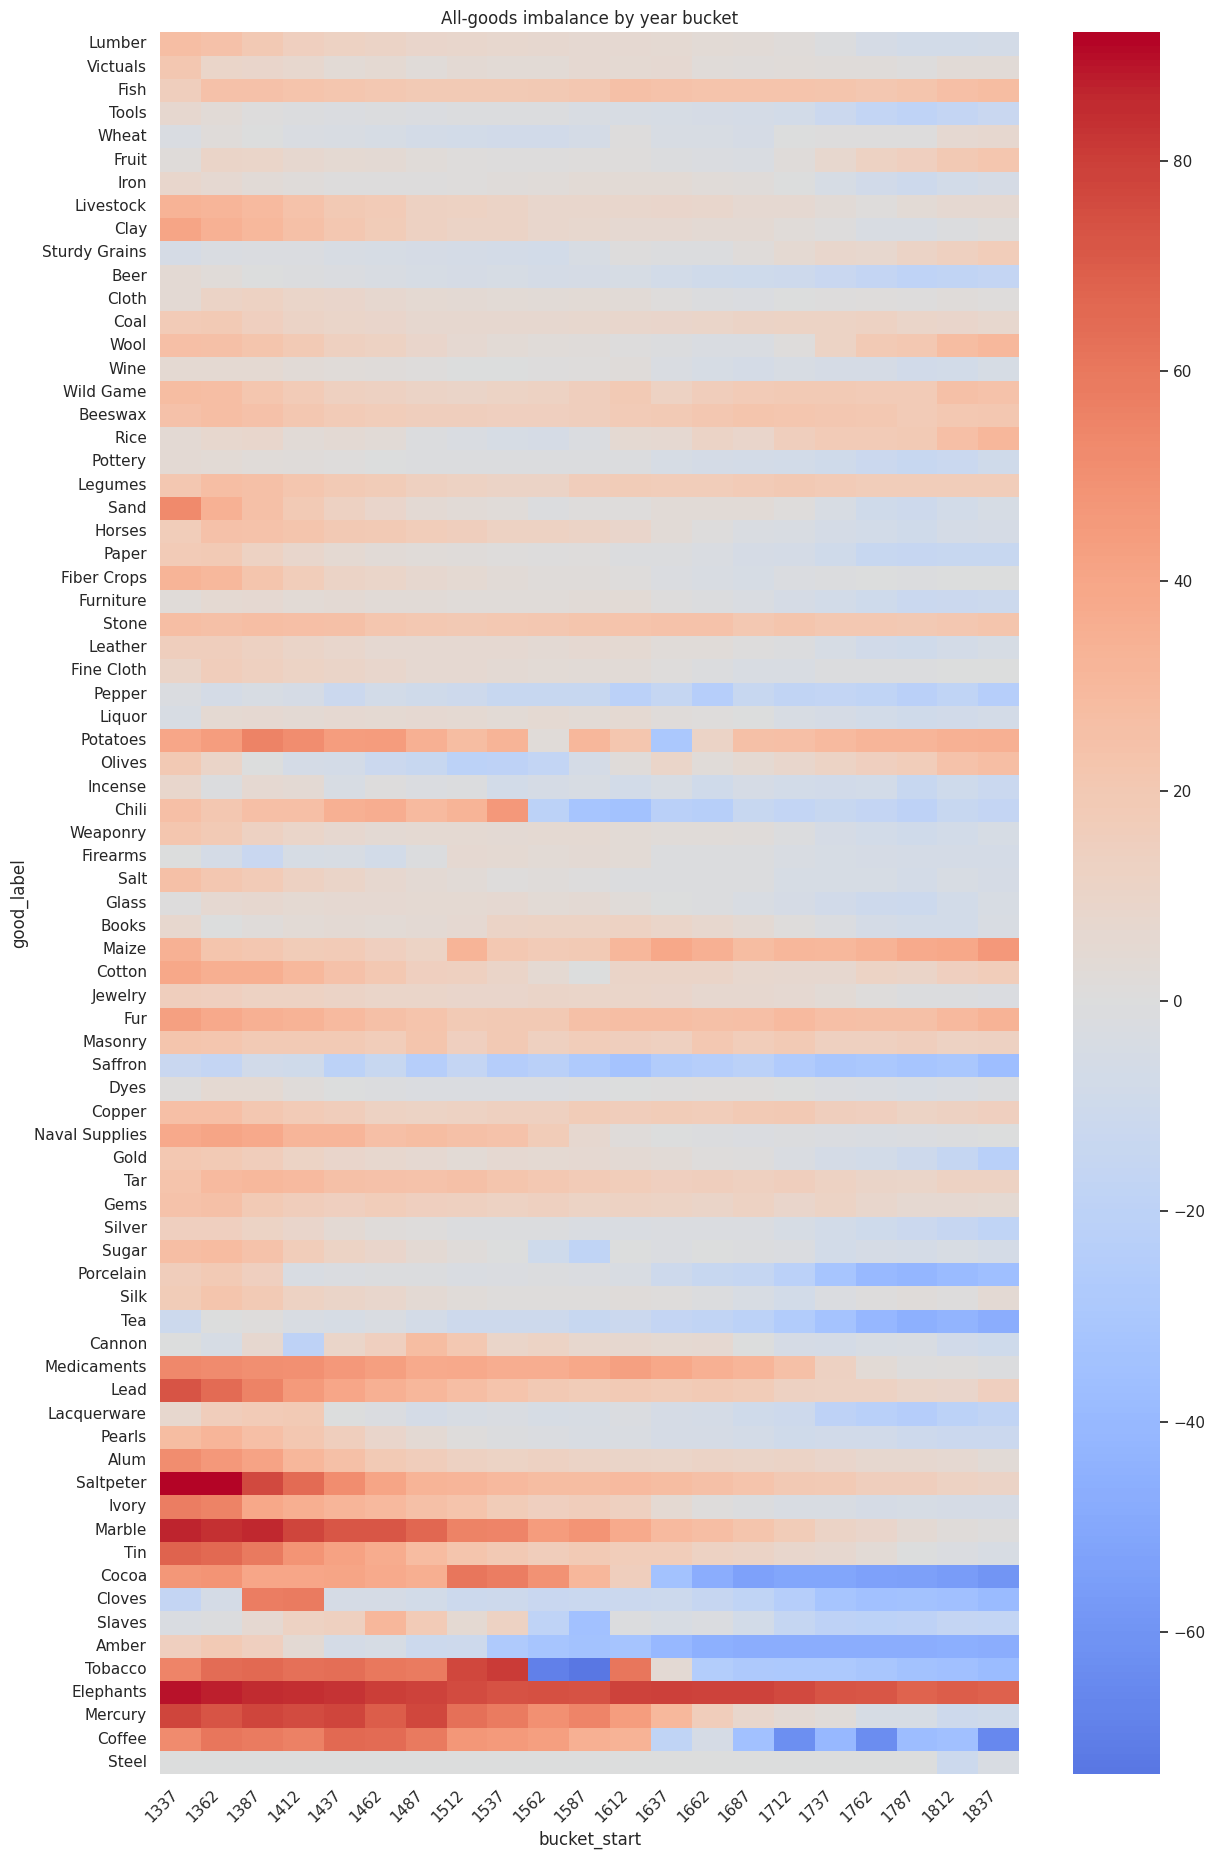

In [8]:
workbench.plot_goods(goods)


## Goods Source / Sink Flows

In [9]:
flows = workbench.flows()
source_breakdown = flows.source_breakdown
sink_breakdown = flows.sink_breakdown
source_ts = flows.source_time_series
sink_ts = flows.sink_time_series
good_consumption_latest = flows.good_consumption_latest
good_consumption_over_time = flows.good_consumption_over_time


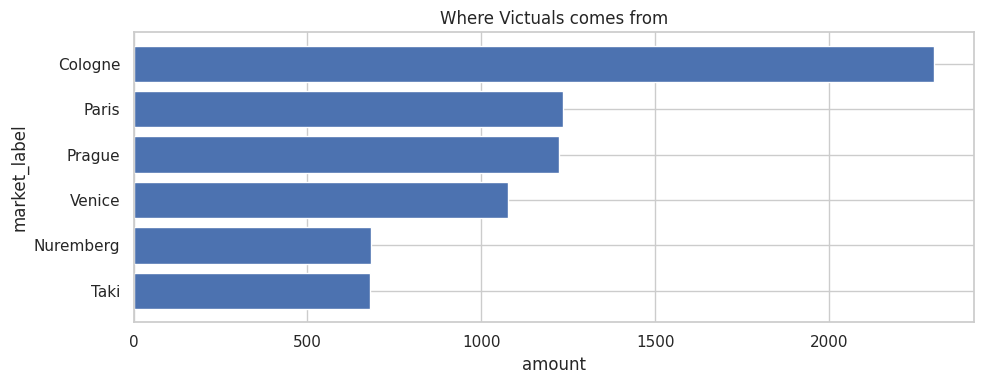

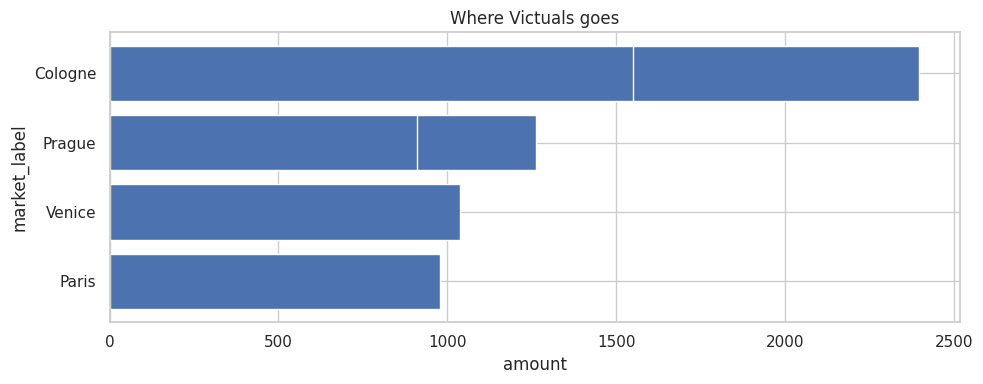

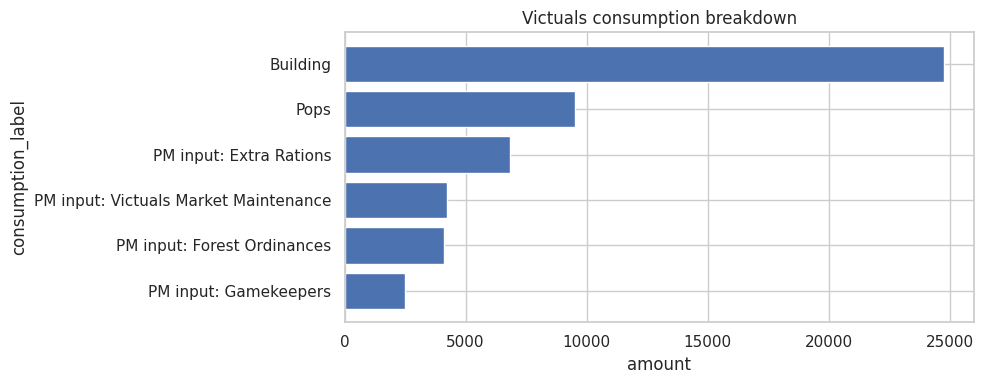

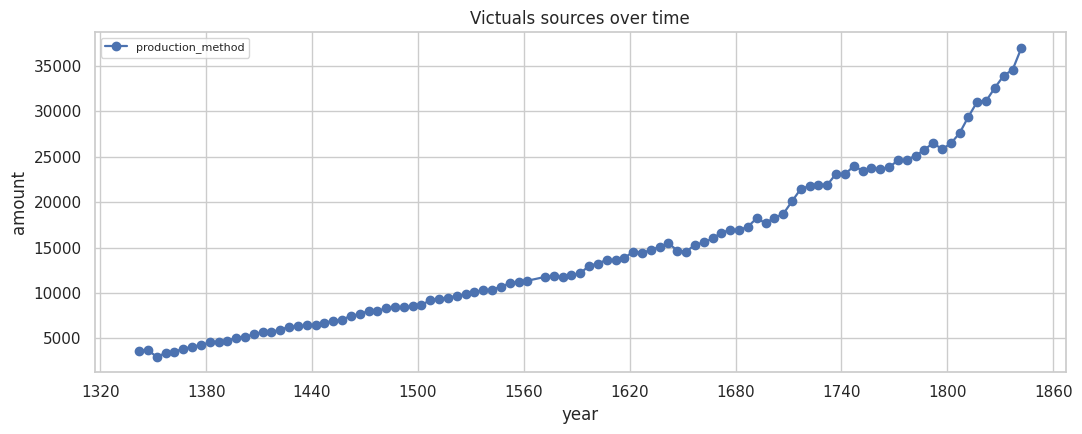

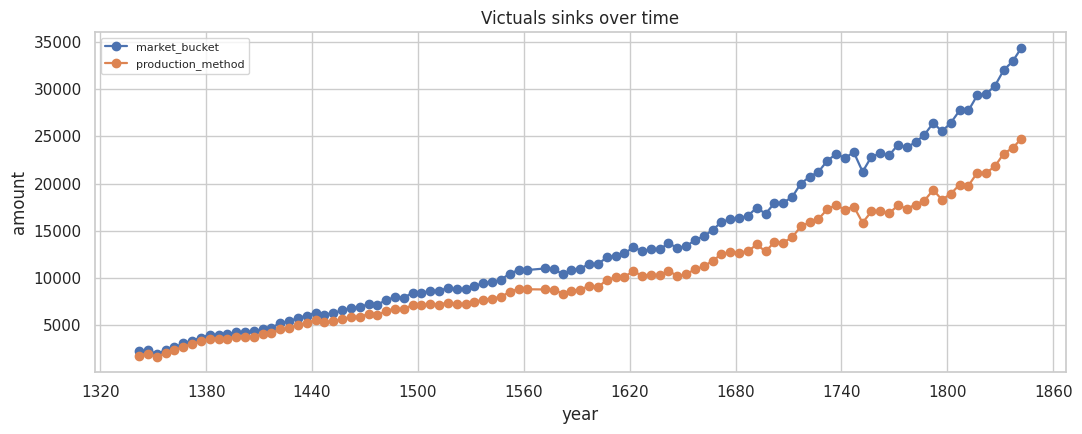

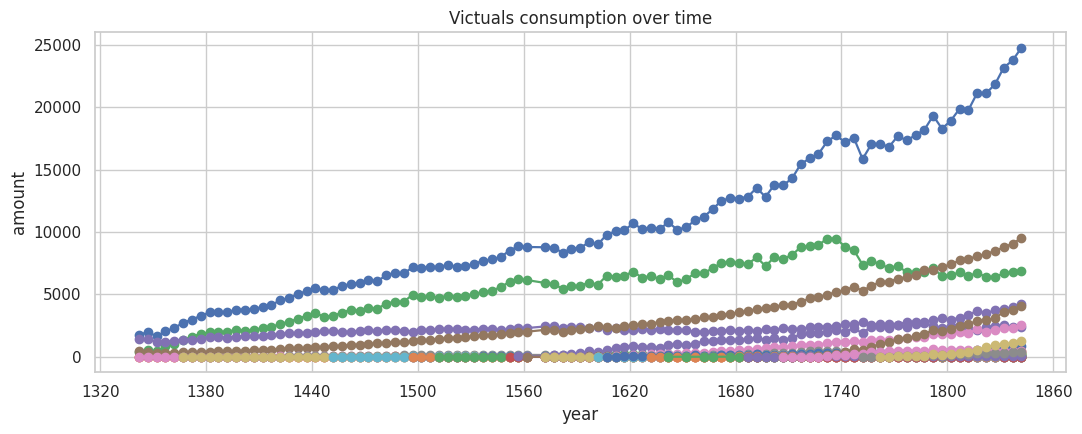

In [10]:
workbench.plot_flows(flows)


## Food Markets

In [11]:
food = workbench.food()
food_rank = food.rank
food_global = food.global_time_series
food_price_distribution = food.price_distribution
food_delta = food.delta


No rows


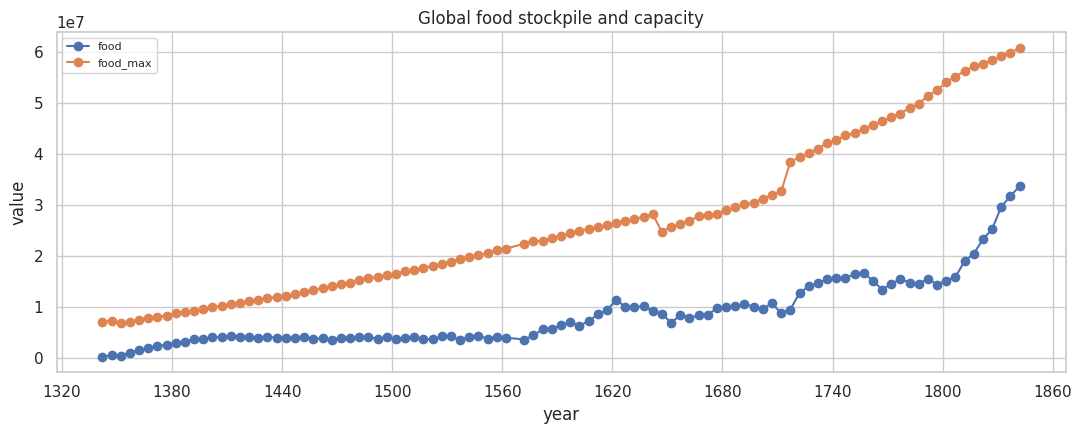

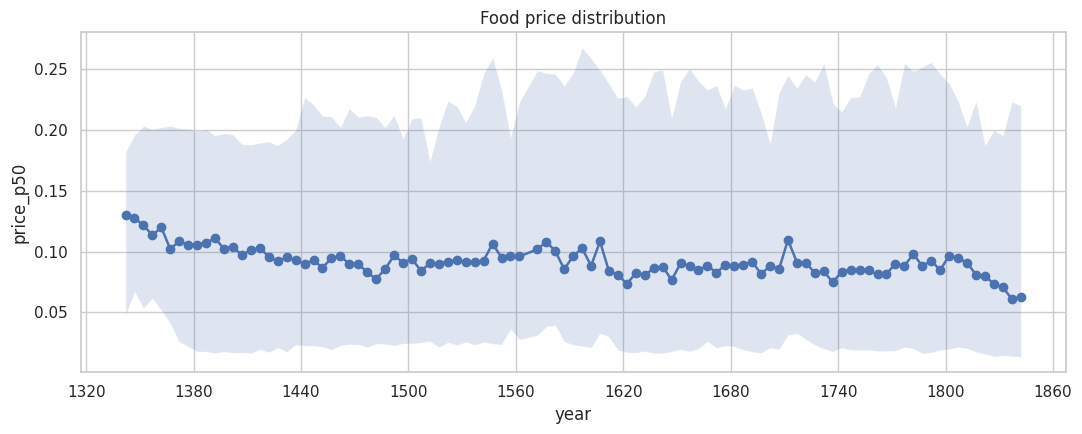

In [12]:
workbench.plot_food(food)


## Buildings And Production Methods

In [13]:
buildings = workbench.buildings()
building_latest = buildings.latest
building_ts = buildings.time_series
pm_adoption = buildings.pm_adoption
pm_preferences = buildings.pm_preferences
pm_regional_preferences_by_slot = buildings.pm_regional_preferences_by_slot
pm_slot_ts = buildings.pm_slot_time_series
pm_usage_by_slot_over_time = buildings.pm_usage_by_slot_over_time
pm_values = buildings.pm_values


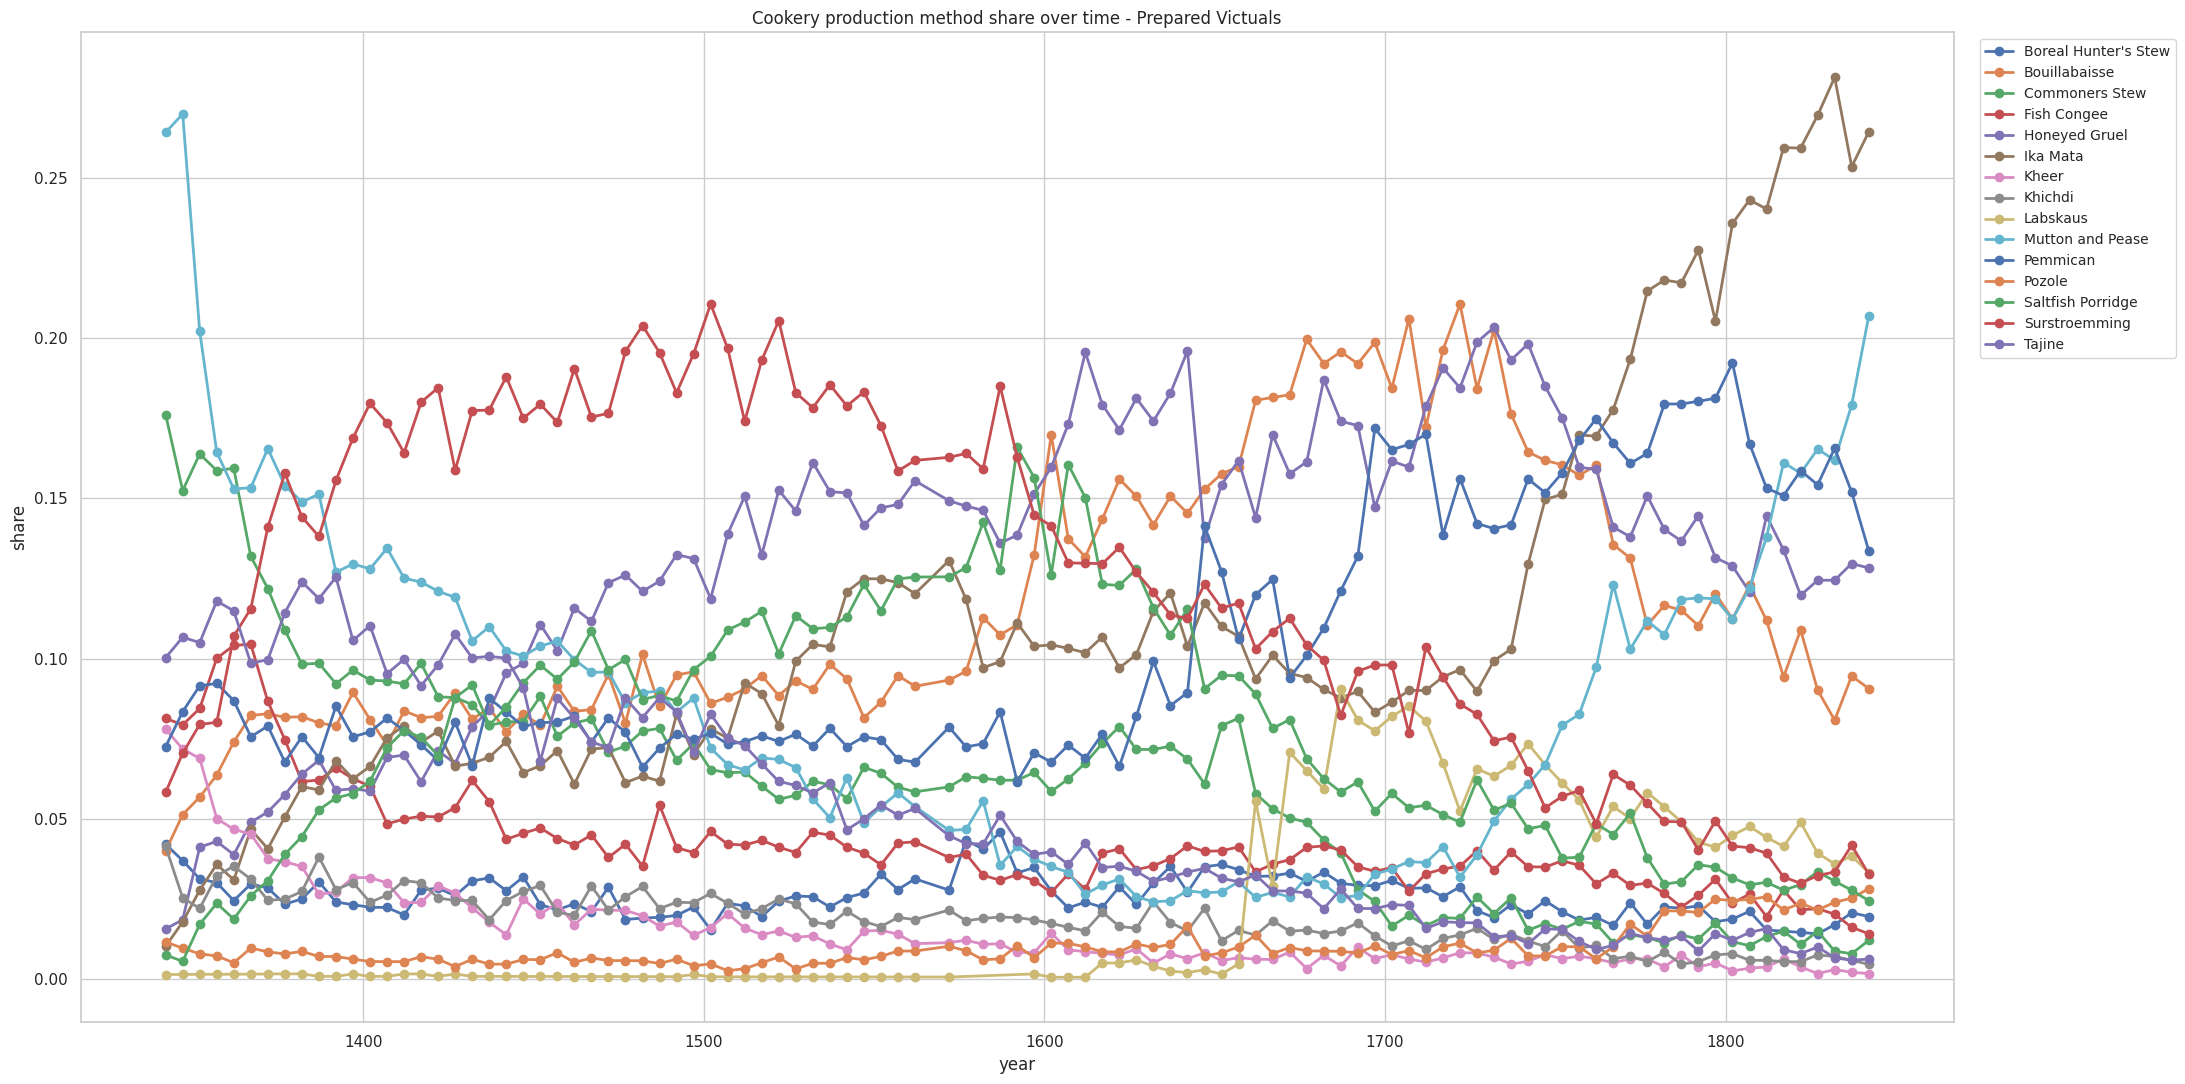

In [14]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

PRODUCTION_METHOD_FIGSIZE = (22, 11)

SLOT_INDEX = 0
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=PRODUCTION_METHOD_FIGSIZE)
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=2.0,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)


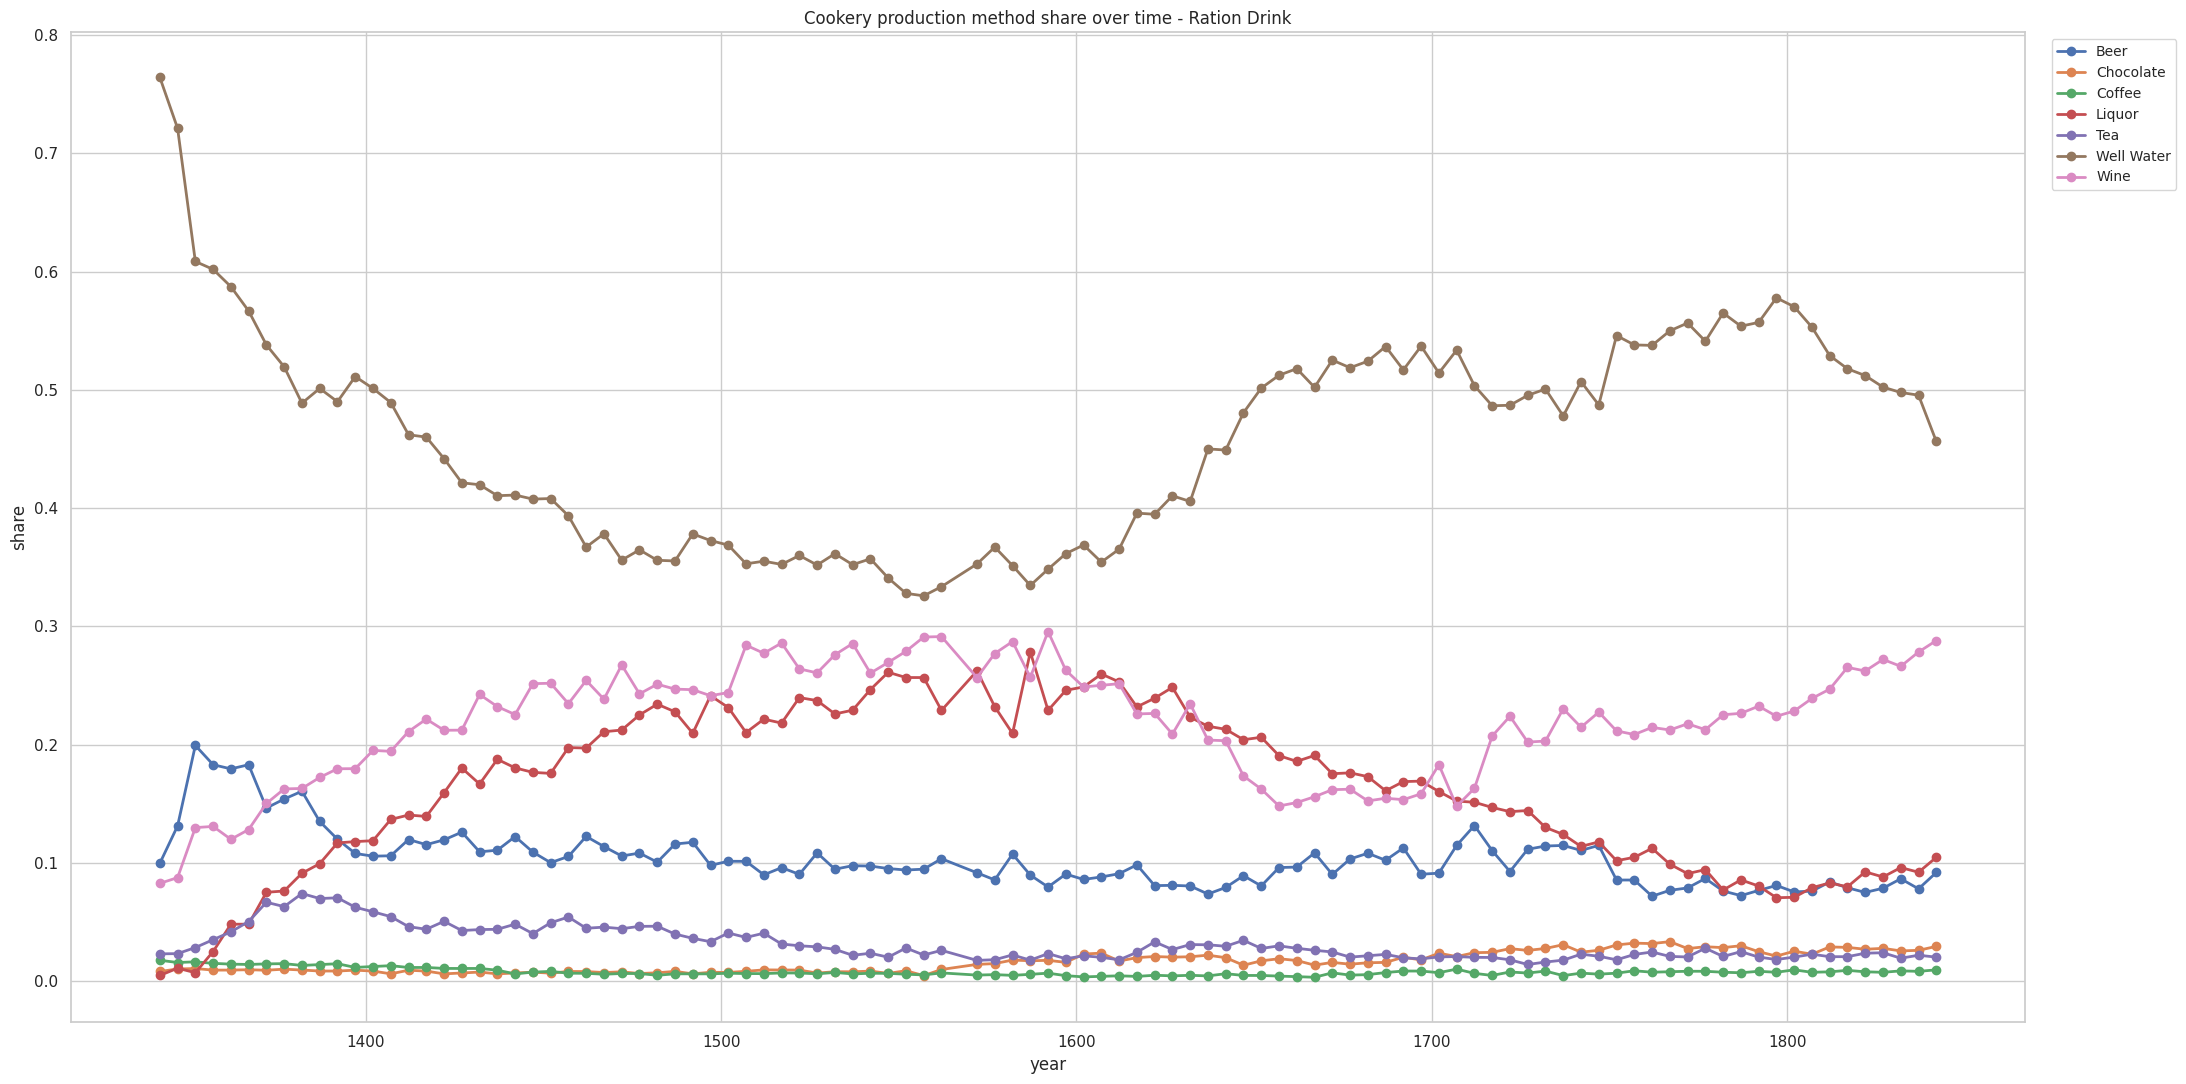

In [15]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

PRODUCTION_METHOD_FIGSIZE = (22, 11)

SLOT_INDEX = 1
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=PRODUCTION_METHOD_FIGSIZE)
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=2.0,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)


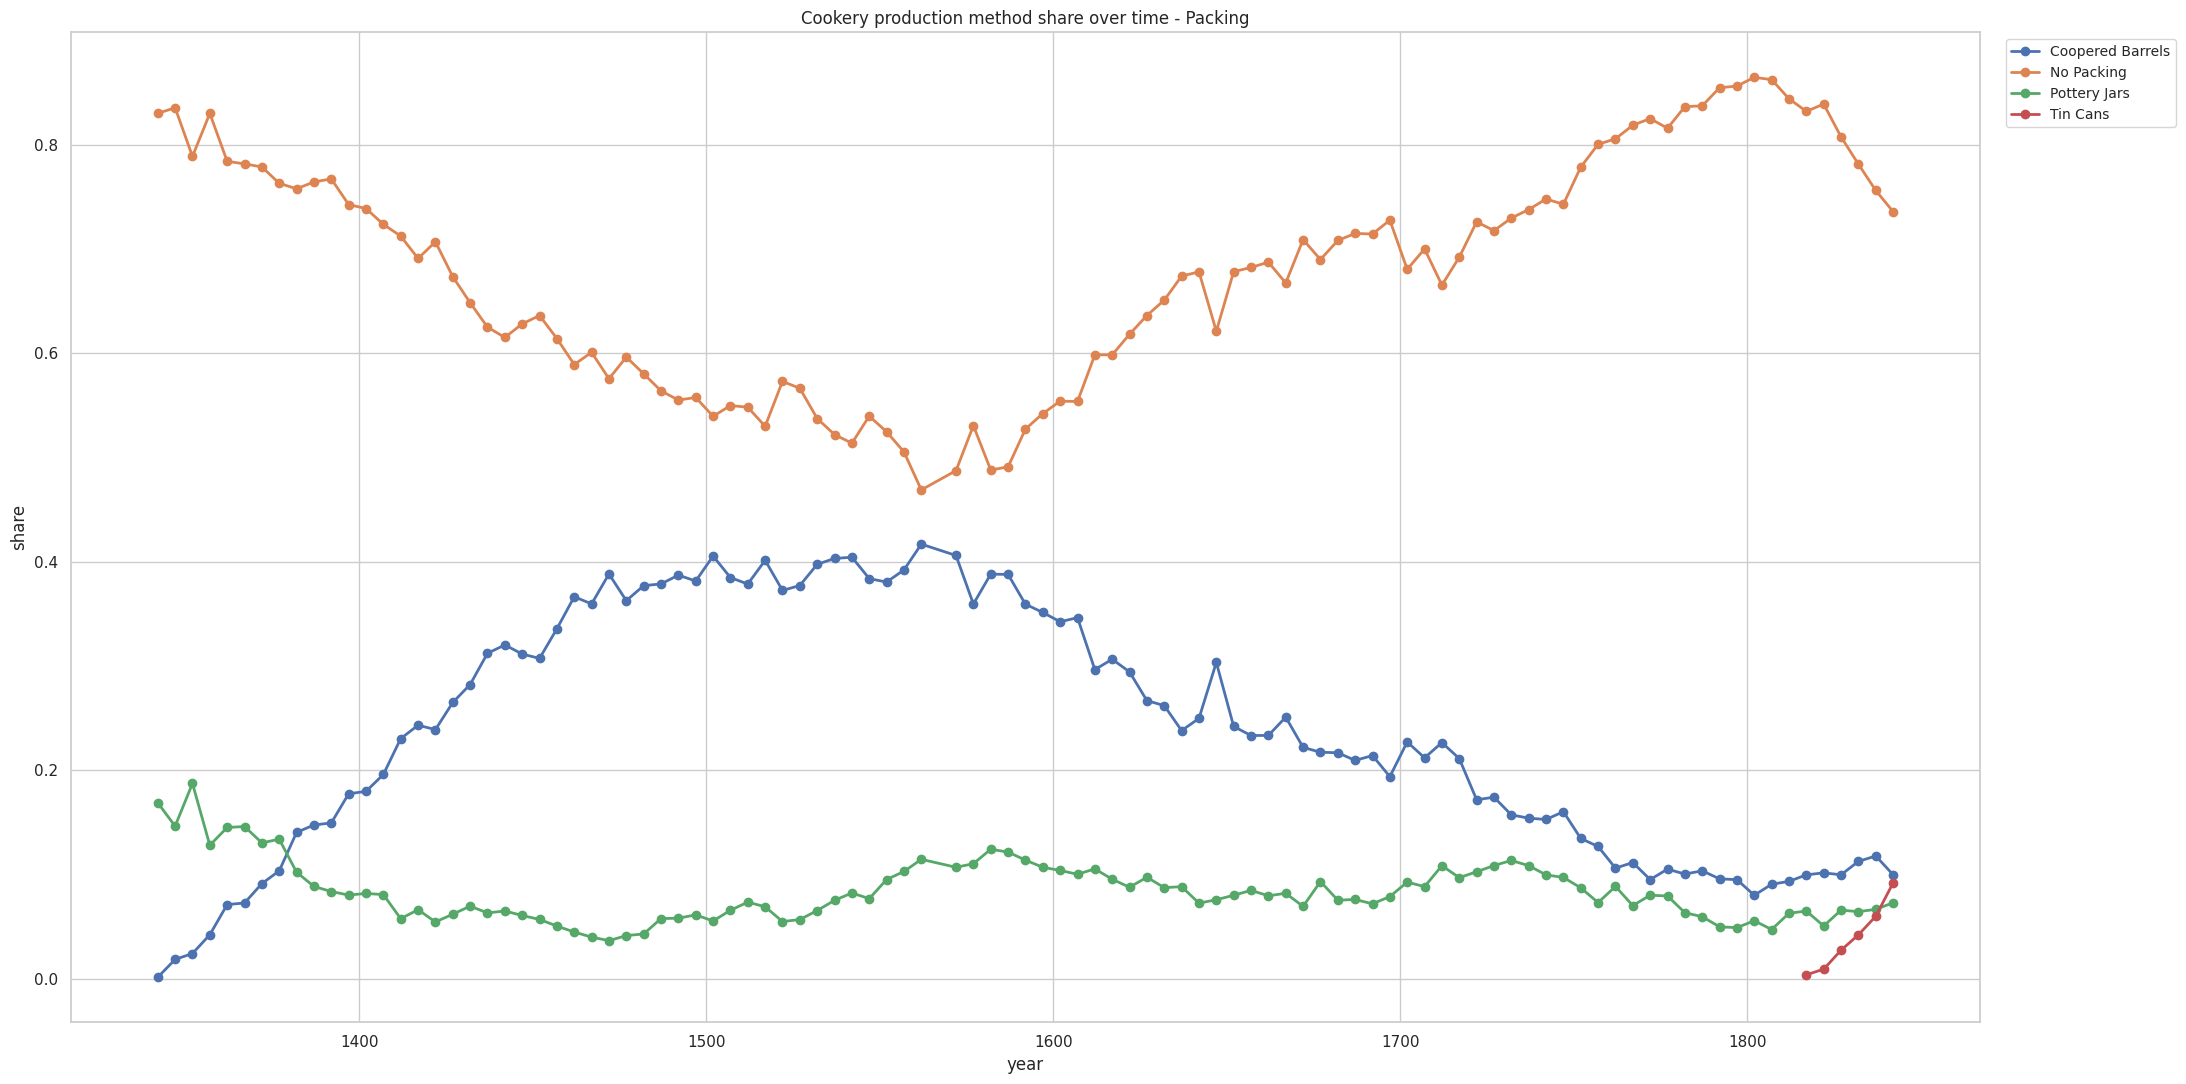

In [16]:
import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

PRODUCTION_METHOD_FIGSIZE = (22, 11)

SLOT_INDEX = 2
null_slot_rows = pm_slot_ts.filter(pl.col("production_method_group_index").is_null())
if null_slot_rows.height == pm_slot_ts.height:
    if SLOT_INDEX == 0:
        pm_slot_plot_ts = pm_slot_ts.with_columns(pl.col("slot_label").alias("_plot_slot_key"))
        slot_key = pm_slot_plot_ts.get_column("_plot_slot_key").drop_nulls().unique().sort().to_list()[0]
    else:
        pm_slot_plot_ts = pm_slot_ts.head(0).with_columns(pl.lit(None, dtype=pl.String).alias("_plot_slot_key"))
        slot_key = None
elif not null_slot_rows.is_empty():
    raise ValueError(
        "pm_slot_ts contains rows without production_method_group_index. "
        "Rerun the buildings cell or rebuild the notebook dataset; slot plots require resolved slot metadata."
    )
else:
    pm_slot_plot_ts = pm_slot_ts.with_columns(
        pl.col("production_method_group_index").cast(pl.String).alias("_plot_slot_key")
    )
    slot_key = str(SLOT_INDEX)

if slot_key is not None:
    slot_frame = pm_slot_plot_ts.filter(pl.col("_plot_slot_key") == slot_key).sort("year")

    if slot_frame.is_empty():
        raise ValueError(f"slot {slot_key}: no data")

    slot_name = (
        slot_frame.get_column("slot_label").drop_nulls().to_list() or [f"slot {slot_key}"]
    )[0]
    methods = slot_frame.get_column("production_method_label").unique().sort().to_list()

    fig, ax = plt.subplots(figsize=PRODUCTION_METHOD_FIGSIZE)
    for method in methods:
        series = slot_frame.filter(pl.col("production_method_label") == method).sort("year")
        ax.plot(
            series["year"].to_list(),
            series["share"].to_list(),
            marker="o",
            linewidth=2.0,
            label=method,
        )
    ax.set_title(
        f"{workbench.building_label} production method share over time - {slot_name}"
    )
    ax.set_xlabel("year")
    ax.set_ylabel("share")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout()
    display(fig, include=["image/png"])
    plt.close(fig)
